# Latin America Real-Time Macro: Offline Data Cartridges, Revision Triangles, and Mankiw-Shapiro Analysis

**How do central banks and macroeconomic researchers in Latin America track monetary policy and economic activity in real time, how large are subsequent data revisions to preliminary releases, and how can immutable, authenticated data cartridges guarantee exact empirical replicability despite upstream statistical agency API shifts?**

**The panel in this notebook is simulated. Read no fact about Latin America out of it.** Every number is generated in the first code cell from the fixed seed `np.random.default_rng(42)`: the Mexican GDP level is a linear trend plus `rng.normal` draws, and the three policy-rate paths are straight lines, the Chilean one flattened at a floor. What is real is the *schema* — the provider names, the series identifiers (`735848`, `SF61745`, `432`, `F022.TPM.TPO.D001.NO.Z.D`) and the units the `puremacro` connectors return — so the notebook exercises the genuine `VintagePanel` and `.pmz` machinery with no network call and no credentials. The `.pmz` cartridge it writes carries `SIMULATED` in its provenance string, so a reader who receives only the cartridge learns the same thing. Nothing here is Banxico, INEGI, BCB or BCCh history.

**Vintages here are snapshot dates, not published editions.** None of these four sources keeps an archive of superseded releases — Banxico's SIE, INEGI's BIE, the BCB's SGS and the BCCh's SIETE all overwrite a series in place. A real-time panel for them therefore has to be *accumulated*: you capture the current edition, wait, capture again, and the revision history extends only back to your own first capture. The eight vintage columns below stand in for eight such captures on eight different days.

Macroeconomic surveillance in emerging markets—particularly across Latin America—requires navigating severe real-time information frictions. Monetary authorities including Banco de México (Banxico), Banco Central do Brasil (BCB), and Banco Central de Chile (BCCh) operate under heightened external vulnerability, where policy interest rates (TIIE objetivo, Taxa Selic, and TPM) must react promptly to emerging domestic output and price developments. However, the national accounts data published by statistical agencies (such as INEGI in Mexico or IBGE in Brazil) are preliminary estimates based on incomplete monthly indicator samples. Over successive months and quarters, these preliminary figures undergo substantial retrospective revisions as late survey responses arrive, informal sector outputs are imputed, and annual benchmark reconciliations occur.

Determining whether macroeconomic revisions represent **news** (efficient forecasting updates incorporating new economic information) or **noise** (transitory measurement errors) is essential for macroeconomic stability. If revisions are primarily noise, central banks that react aggressively to initial releases inadvertently inject spurious volatility into the real economy. If revisions represent news, preliminary releases efficiently summarize all available data and policy should respond immediately. Furthermore, empirical research in Latin American macroeconomics is frequently disrupted when central bank or statistical agency APIs alter endpoints, modify JSON response schemas, or require proprietary authentication tokens. Self-verifying `.pmz` data cartridges package multi-country real-time vintage panels into immutable, cryptographically hashed capsules that execute completely offline in browser and Pyodide environments. This notebook demonstrates the full workflow: assembling a multi-country Latin American vintage panel, packaging and verifying offline `.pmz` cartridges, constructing real-time revision triangles, and conducting Mankiw-Shapiro (1986) news versus noise econometrics.

## The method in math — Latin America Real-Time Vintages, Revision Triangles, and Mankiw-Shapiro Econometrics

**1. Real-Time Vintage Matrix and Revision Dynamics.** Let $y_{i, t, v}$ denote the value of macroeconomic indicator $i$ for reference quarter $t$ published in vintage edition $v$ (where publication date $v \ge t$). For a balanced vintage sequence, the historical revision triangle matrix $\mathbf{T}[t, v]$ arranges reference dates along rows and publication vintages along columns:
$$ \mathbf{T} = \begin{bmatrix} y_{t_1, v_1} & y_{t_1, v_2} & \dots & y_{t_1, v_K} \\ \text{NaN} & y_{t_2, v_2} & \dots & y_{t_2, v_K} \\ \vdots & \vdots & \ddots & \vdots \\ \text{NaN} & \text{NaN} & \dots & y_{t_K, v_K} \end{bmatrix}. $$
Let $y_t^{(0)} = y_{t, v_0(t)}$ denote the initial preliminary release and $y_t^{(F)} = y_{t, v_{\max}}$ the latest benchmark release. The total revision is defined as:
$$ r_t \equiv y_t^{(F)} - y_t^{(0)}. $$
For Banxico, INEGI, the BCB and the BCCh the index $v$ is a **snapshot date**, not a publication date: each provider serves only the current edition of a series and overwrites it in place, so $v$ records the day a fetch was stored locally and $v_0(t)$ is the first capture after quarter $t$ ended, not the day the agency first published it.

**2. Mankiw-Shapiro (1986) News vs. Noise Econometric Tests.** Under rational expectations and efficient statistical agency reporting, revisions are classified into two competing structural hypotheses:
- **News Hypothesis ($H_{\text{News}}$):** The preliminary release $y_t^{(0)}$ is an optimal mathematical projection of the final value $y_t^{(F)}$ onto the preliminary information set $\Omega_0$. The revision $r_t$ represents unpredictable innovation news and must be orthogonal to $y_t^{(0)}$:
  $$ r_t = \alpha_p + \beta_p y_t^{(0)} + \varepsilon_{p, t}, \quad H_0^{\text{News}}: \beta_p = 0. $$
- **Noise Hypothesis ($H_{\text{Noise}}$):** The preliminary release is the true final value contaminated with classical measurement error $u_t$: $y_t^{(0)} = y_t^{(F)} + u_t$, where $\operatorname{Cov}(y_t^{(F)}, u_t) = 0$. The revision $r_t = -u_t$ is correlated with the preliminary release but must be orthogonal to the final release $y_t^{(F)}$:
  $$ r_t = \alpha_f + \beta_f y_t^{(F)} + \varepsilon_{f, t}, \quad H_0^{\text{Noise}}: \beta_f = 0. $$
The noise share of preliminary release variance is quantified as:
$$ \text{Noise Share} = \max(0, -\beta_p) = \frac{\operatorname{Var}(u_t)}{\operatorname{Var}(y_t^{(0)})}. $$

**3. Cryptographic Data Cartridge Authentication.** Data cartridges (`.pmz`) guarantee offline empirical replicability via cryptographic digest hashing:
$$ \mathcal{H}_{\text{data}} = \operatorname{SHA256}(\operatorname{bytes}(df)), \quad \text{verified on unpack against metadata manifest.} $$

## Intuition

**Intuition.** Policymakers at Banco de México, Banco Central do Brasil, and Banco Central de Chile make real-time interest rate decisions based on imperfect preliminary snapshots of economic growth and inflation. When the national statistical institute releases initial GDP growth for the previous quarter, that estimate reflects only a fraction of completed business surveys and relies heavily on statistical imputation for informal economic activity. Over subsequent quarters, as comprehensive corporate tax filings and late census data are processed, statistical agencies publish revised figures that can alter the perceived stance of the business cycle.

The Mankiw-Shapiro econometric framework evaluates how policymakers should interpret these revisions. If statistical agencies construct preliminary releases as rational forecasts given incomplete information, revisions represent genuine economic *news*. In this scenario, revisions cannot be forecasted from the preliminary data ($\beta_p = 0$), implying that central banks cannot improve upon the initial release and should treat it as an unbiased signal. Conversely, if preliminary estimates are corrupted by classical measurement error (*noise*), the revision is negatively correlated with the initial release ($\beta_p < 0$) and orthogonal to the final benchmark ($\beta_f = 0$). Under the noise hypothesis, central bankers who react aggressively to preliminary growth numbers end up chasing statistical artifacts, amplifying output volatility.

To enable rigorous macroeconomic analysis without dependency on external network sockets, API rate limits, or credentials, `puremacro` introduces self-verifying data cartridges (`.pmz`). The cartridge bundles multi-country vintage panels, canonical series metadata, and cryptographic SHA-256 signatures into a single compressed binary capsule. When loaded offline, the cartridge verifies data integrity and exposes the full `VintagePanel` analytical interface (`coverage()`, `as_of()`, `triangle()`, `revisions()`, and `news_or_noise()`), guaranteeing 100% browser and Pyodide compatibility.

The panel exercised below is simulated precisely so that this demonstration can be checked. Because we know the data-generating process — a deterministic trend, measurement noise planted only in recent editions, unrevised policy-rate lines — we can say exactly what each diagnostic *should* report, and the assertions in each cell hold the library to it. A real capture from the four connectors would show the same machinery on numbers nobody controls; it would also need a network, credentials for Banxico, and months of accumulated snapshots before any revision existed to test.

In [1]:
# Preamble: import numerical libraries, plotting style, and realtime panel tools
import sys
from pathlib import Path
import tempfile
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.fetch.realtime import (
    VintagePanel,
    pack_realtime_cartridge,
    load_realtime_cartridge,
)

# Set deterministic random seed for reproducibility
rng = np.random.default_rng(42)

print("Latin America Real-Time Ecosystem: Banxico, INEGI, BCB, BCCh")

Latin America Real-Time Ecosystem: Banxico, INEGI, BCB, BCCh


In [2]:
# --- Experiment 1: Assemble a SIMULATED Multi-Country Latin America Vintage Panel ---
# EVERY VALUE BELOW IS GENERATED IN THIS CELL. The provider names, series identifiers
# and units are the real ones the puremacro connectors return, so the panel exercises
# the genuine schema offline (no network call, no credentials anywhere in this file).
# The numbers themselves are stylized paths invented for this notebook and are NOT
# Banxico, INEGI, BCB or BCCh history -- do not quote them as facts about the region.
#
# Construct quarterly reference periods: 2022Q1 to 2025Q3 (15 reference quarters).
# Publication vintages: 8 quarterly SNAPSHOT DATES spanning 2024Q1 to 2025Q4. All four
# of these sources publish only the current edition of a series, so a real panel is
# accumulated one capture at a time and its revision history reaches back only as far
# as the first capture; the 8 columns here stand in for 8 such captures.
ref_dates = pd.date_range("2022-01-01", "2025-07-01", freq="QS").strftime("%Y-%m-%d").tolist()
vintage_dates = pd.date_range("2024-01-01", "2025-10-01", freq="QS").strftime("%Y-%m-%d").tolist()

rows = []
for v_idx, v in enumerate(vintage_dates):
    for d_idx, d in enumerate(ref_dates):
        if d <= v:
            # Mexico: Real GDP level (INEGI indicator 735848). Simulated preliminary
            # measurement noise is planted only in editions published within 180 days
            # of the reference quarter; older editions repeat the same trend value.
            base_gdp = 24000000.0 + 150000.0 * d_idx
            noise = float(rng.normal(0, 50000.0)) if d == v or (pd.to_datetime(v) - pd.to_datetime(d)).days <= 180 else 0.0
            rows.append({
                "country": "MEX", "variable": "gdp_real", "date": d, "vintage": v,
                "value": base_gdp + noise, "provider": "inegi", "series_id": "735848", "units": "level"
            })
            # Mexico: Policy rate (Banxico TIIE objetivo, series SF61745).
            # Simulated straight line, 11.25% down to 7.75% at 25 bp per quarter.
            rows.append({
                "country": "MEX", "variable": "policy_rate", "date": d, "vintage": v,
                "value": 11.25 - 0.25 * d_idx, "provider": "banxico", "series_id": "SF61745", "units": "rate"
            })
            # Brazil: Policy rate (BCB Taxa Selic, series 432).
            # Simulated straight line, 12.75% down to 5.75% at 50 bp per quarter.
            rows.append({
                "country": "BRA", "variable": "policy_rate", "date": d, "vintage": v,
                "value": 12.75 - 0.50 * d_idx, "provider": "bcb", "series_id": "432", "units": "rate"
            })
            # Chile: Policy rate (BCCh TPM, series F022.TPM.TPO.D001.NO.Z.D).
            # Simulated straight line, 9.50% down to a 3.00% floor, so the synthetic
            # rate never reaches zero or turns negative.
            rows.append({
                "country": "CHL", "variable": "policy_rate", "date": d, "vintage": v,
                "value": max(3.00, 9.50 - 0.50 * d_idx), "provider": "bcch", "series_id": "F022.TPM.TPO.D001.NO.Z.D", "units": "rate"
            })

df_raw = pd.DataFrame(rows)
panel_raw = VintagePanel(df_raw)
min_policy_rate = float(df_raw.loc[df_raw["variable"] == "policy_rate", "value"].min())

print(f"Constructed Multi-Country Vintage Panel:")
print("  Data Provenance    : SIMULATED (stylized paths on real provider/series identifiers)")
print(f"  Total Observations : {len(panel_raw):,}")
print(f"  Countries Included : {panel_raw.countries}")
print(f"  Macro Variables    : {panel_raw.variables}")
print(f"  Reference Periods  : {len(ref_dates)} quarters ({ref_dates[0]} to {ref_dates[-1]})")
print(f"  Vintage Snapshots  : {len(vintage_dates)} captures ({vintage_dates[0]} to {vintage_dates[-1]})")
print(f"  Lowest Policy Rate : {min_policy_rate:.2f}% (simulated floor)")

# Panel structural assertions
assert panel_raw.countries == ["BRA", "CHL", "MEX"]
assert "policy_rate" in panel_raw.variables
assert "gdp_real" in panel_raw.variables
assert len(panel_raw) > 300
# A simulated policy rate that goes non-positive would be economically absurd, and it
# would be undefined under the log transform the revision tools apply to a series
# declared units="level"; these three declare units="rate", which is read in levels.
assert min_policy_rate > 0.0, "Simulated policy rates must stay strictly positive"

Constructed Multi-Country Vintage Panel:
  Data Provenance    : SIMULATED (stylized paths on real provider/series identifiers)
  Total Observations : 396
  Countries Included : ['BRA', 'CHL', 'MEX']
  Macro Variables    : ['gdp_real', 'policy_rate']
  Reference Periods  : 15 quarters (2022-01-01 to 2025-07-01)
  Vintage Snapshots  : 8 captures (2024-01-01 to 2025-10-01)
  Lowest Policy Rate : 3.00% (simulated floor)


In [3]:
# --- Experiment 2: Self-Verifying Cryptographic Cartridge Packaging & Loading ---
# Package panel into an offline .pmz cartridge with SHA-256 verification
with tempfile.TemporaryDirectory() as tmp_dir:
    cartridge_file = Path(tmp_dir) / "latam_realtime_macro.pmz"
    pack_realtime_cartridge(
        panel_raw,
        cartridge_file,
        source="SIMULATED panel on Banxico, INEGI, BCB and BCCh series identifiers",
        vintage="2026-04-01",
        notes=(
            "Latin America real-time vintage cartridge for puremacro showcase 58. "
            "SYNTHETIC DATA: values are generated from a fixed seed, not fetched from "
            "any provider. Vintage columns are snapshot dates, not published editions."
        ),
    )
    assert cartridge_file.exists(), "Cartridge file must be created on disk"
    loaded_panel = load_realtime_cartridge(cartridge_file, verify=True)

print(f"Portable Cartridge Authentication:")
print(f"  SHA-256 Digest Verification : SUCCESS")
print(f"  Declared Provenance         : {loaded_panel.metadata['provenance_source']}")
print(f"  Loaded Countries            : {loaded_panel.countries}")
print(f"  Loaded Variables            : {loaded_panel.variables}")
print(f"  Loaded Record Count         : {len(loaded_panel):,}")

# Cartridge integrity assertions
assert isinstance(loaded_panel, VintagePanel)
assert loaded_panel.countries == ["BRA", "CHL", "MEX"]
assert len(loaded_panel) == len(panel_raw)
# A reader who receives only the .pmz must still learn the data is simulated.
assert "SIMULATED" in loaded_panel.metadata["provenance_source"]

Portable Cartridge Authentication:
  SHA-256 Digest Verification : SUCCESS
  Declared Provenance         : SIMULATED panel on Banxico, INEGI, BCB and BCCh series identifiers
  Loaded Countries            : ['BRA', 'CHL', 'MEX']
  Loaded Variables            : ['gdp_real', 'policy_rate']
  Loaded Record Count         : 396


In [4]:
# --- Experiment 3: Real-Time Coverage, As-Of Cross-Section, and Revision Triangles ---
cov_df = loaded_panel.coverage()
as_of_2025 = loaded_panel.as_of("2025-06-01")
tri_df = loaded_panel.triangle("MEX", "gdp_real")
rev_df = loaded_panel.revisions("MEX", "gdp_real")

print(f"Real-Time Panel Analysis:")
print(f"  Coverage Table Dimensions     : {cov_df.shape}")
print(f"  As-Of 2025-06-01 Observations : {len(as_of_2025)}")
print(f"  Mexico GDP Revision Triangle  : {tri_df.shape[0]} reference dates x {tri_df.shape[1]} vintages")
print(f"  Total Revisions Extracted     : {len(rev_df)} revision pairs")
print(f"  Mean Revision (signed)        : {rev_df['revision'].mean():.4f} percentage points")
print(f"  Mean Absolute Revision        : {rev_df['revision'].abs().mean():.4f} percentage points")

# Coverage and revision assertions
assert not cov_df.empty, "Coverage table must not be empty"
assert not as_of_2025.empty, "As-of slice must return observations"
assert tri_df.shape[1] == len(vintage_dates), "Triangle must have columns for all vintages"
assert len(rev_df) > 0, "Revision pairs must be non-empty"
assert "revision" in rev_df.columns

Real-Time Panel Analysis:
  Coverage Table Dimensions     : (4, 11)
  As-Of 2025-06-01 Observations : 42
  Mexico GDP Revision Triangle  : 15 reference dates x 8 vintages
  Total Revisions Extracted     : 7 revision pairs
  Mean Revision (signed)        : 0.0367 percentage points
  Mean Absolute Revision        : 0.1167 percentage points


In [5]:
# --- Experiment 4: Mankiw-Shapiro (1986) News vs. Noise Econometric Testing ---
ms_res = loaded_panel.news_or_noise("MEX", "gdp_real")
# min_obs defaults to 12; this simulated panel has 7 observable revision pairs per series.
ms_panel = loaded_panel.news_or_noise_panel(min_obs=len(rev_df))
print(ms_panel[["country", "variable", "n_obs", "beta_on_preliminary", "verdict", "ok", "note"]].to_string(index=False))

print(f"Mankiw-Shapiro (1986) News vs. Noise Results (Mexico Real GDP):")
print(f"  Observations Analyzed : {ms_res.n_obs}")
print(f"  Test Verdict          : {ms_res.verdict}")
print(f"  News Hypothesis (H0: beta_p = 0):")
print(f"    beta_p              : {ms_res.beta_on_preliminary:.4f} (SE = {ms_res.se_beta_on_preliminary:.4f})")
print(f"    p-value             : {ms_res.p_beta_on_preliminary:.4e} (Rejects News = {ms_res.rejects_news})")
print(f"  Noise Hypothesis (H0: beta_f = 0):")
print(f"    beta_f              : {ms_res.beta_on_final:.4f} (SE = {ms_res.se_beta_on_final:.4f})")
print(f"    p-value             : {ms_res.p_beta_on_final:.4e} (Rejects Noise = {ms_res.rejects_noise})")
print(f"  Noise Share Metric    : {ms_res.noise_share * 100:.2f}%")

# Econometric test assertions
assert hasattr(ms_res, "verdict"), "Result must contain verdict attribute"
assert ms_res.n_obs > 0, "Number of observations must be positive"
assert 0.0 <= ms_res.p_beta_on_preliminary <= 1.0, "P-value must lie in [0, 1]"
assert 0.0 <= ms_res.p_beta_on_final <= 1.0, "P-value must lie in [0, 1]"
gdp_row = ms_panel[(ms_panel["country"] == "MEX") & (ms_panel["variable"] == "gdp_real")]
assert bool(gdp_row["ok"].iloc[0]), "The panel must estimate the Mexican GDP test, not just list it"
assert np.isclose(gdp_row["beta_on_preliminary"].iloc[0], ms_res.beta_on_preliminary), "Panel row must match the single-series test"
rate_rows = ms_panel[ms_panel["variable"] == "policy_rate"]
assert not rate_rows["ok"].any(), "Unrevised policy rates have no revisions to test"
assert rate_rows["note"].str.contains("zero").all(), "Each skipped row must say why"

country    variable  n_obs  beta_on_preliminary verdict    ok                                                                                             note
    MEX    gdp_real      7            -0.894717 neither  True                                                                                                 
    BRA policy_rate      7                  NaN         False test not estimable: every revision is exactly zero, so the news/noise regressions are degenerate
    CHL policy_rate      7                  NaN         False test not estimable: every revision is exactly zero, so the news/noise regressions are degenerate
    MEX policy_rate      7                  NaN         False test not estimable: every revision is exactly zero, so the news/noise regressions are degenerate
Mankiw-Shapiro (1986) News vs. Noise Results (Mexico Real GDP):
  Observations Analyzed : 7
  Test Verdict          : neither
  News Hypothesis (H0: beta_p = 0):
    beta_p              : -0.8947 (SE = 0.0

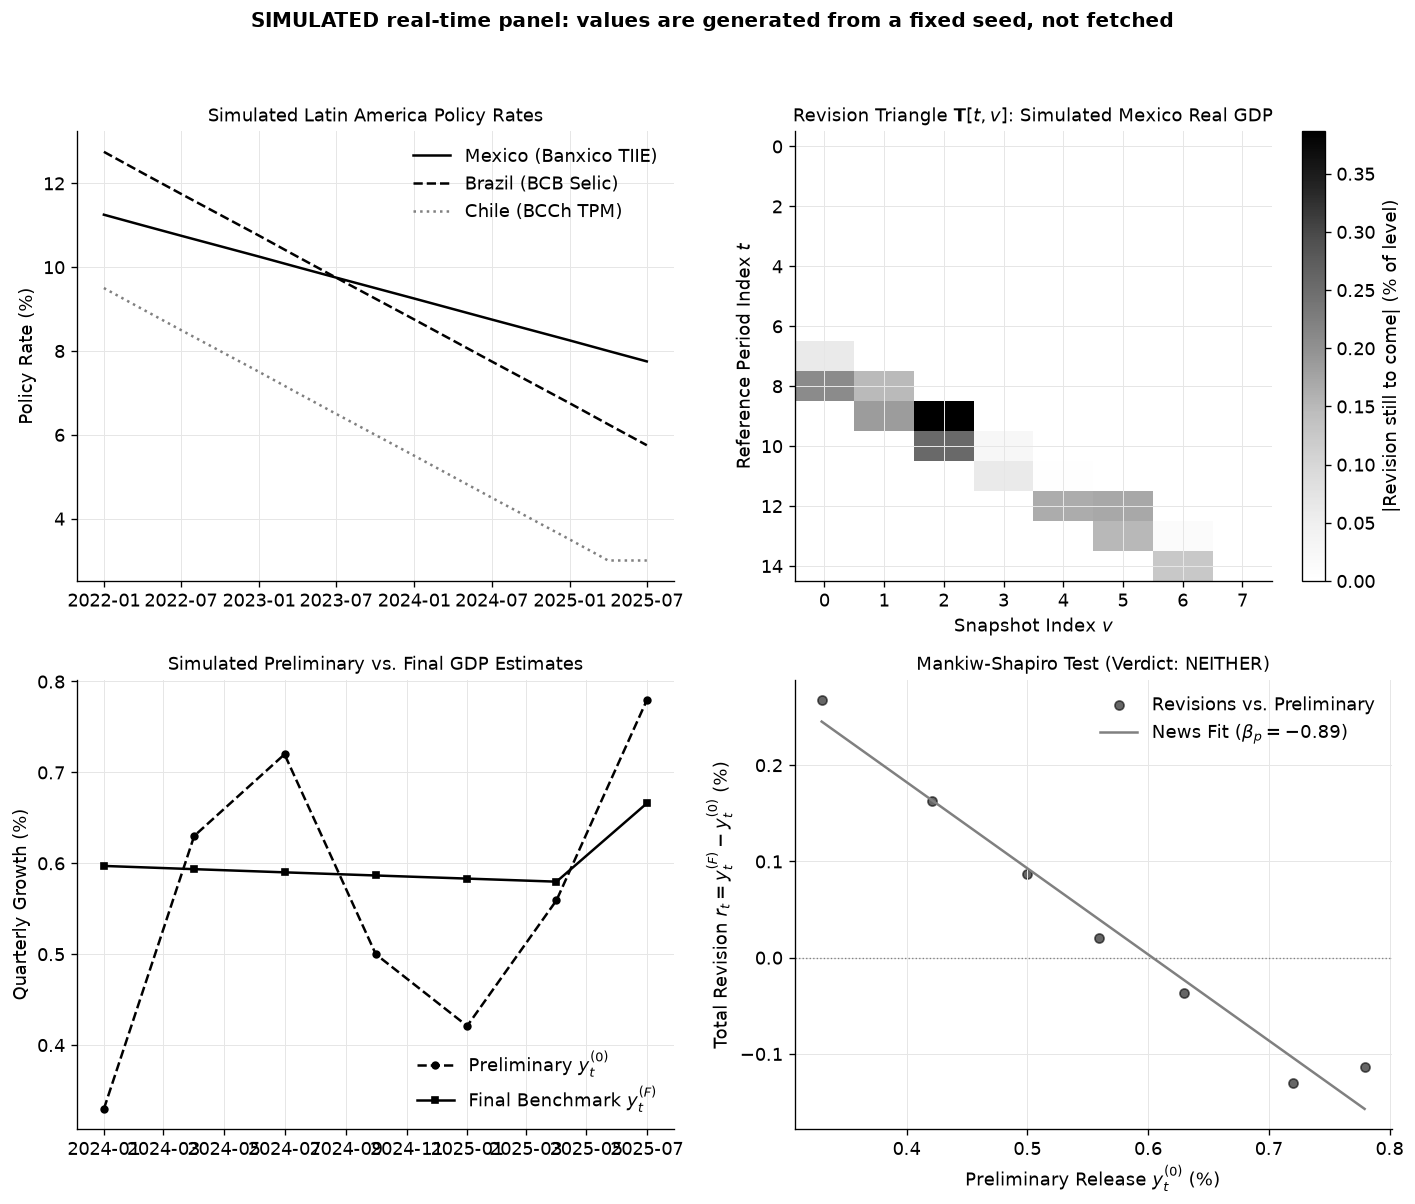

In [6]:
# --- Hero Visualizations: Latin America Real-Time Macro Dashboard (SIMULATED panel) ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Subplot 1: Central Bank Policy Rates Across Latin America
ax1 = axes[0, 0]
mex_rates = loaded_panel.df[(loaded_panel.df["country"] == "MEX") & (loaded_panel.df["variable"] == "policy_rate") & (loaded_panel.df["vintage"] == vintage_dates[-1])]
bra_rates = loaded_panel.df[(loaded_panel.df["country"] == "BRA") & (loaded_panel.df["variable"] == "policy_rate") & (loaded_panel.df["vintage"] == vintage_dates[-1])]
chl_rates = loaded_panel.df[(loaded_panel.df["country"] == "CHL") & (loaded_panel.df["variable"] == "policy_rate") & (loaded_panel.df["vintage"] == vintage_dates[-1])]

ax1.plot(pd.to_datetime(mex_rates["date"]), mex_rates["value"], color=_nbstyle.S1["color"], linestyle=_nbstyle.S1["linestyle"], label="Mexico (Banxico TIIE)")
ax1.plot(pd.to_datetime(bra_rates["date"]), bra_rates["value"], color=_nbstyle.S2["color"], linestyle=_nbstyle.S2["linestyle"], label="Brazil (BCB Selic)")
ax1.plot(pd.to_datetime(chl_rates["date"]), chl_rates["value"], color=_nbstyle.S3["color"], linestyle=_nbstyle.S3["linestyle"], linewidth=1.5, label="Chile (BCCh TPM)")
ax1.set_title("Simulated Latin America Policy Rates", fontsize=11)
ax1.set_ylabel("Policy Rate (%)")
ax1.legend(frameon=False)

# Subplot 2: Mexico Real GDP Revision Triangle, as the revision still to come in each cell
ax2 = axes[0, 1]
latest = tri_df.ffill(axis=1).iloc[:, -1]
still_to_come = 100.0 * (latest.to_numpy()[:, None] / tri_df.to_numpy() - 1.0)   # % of the edition's value
im = ax2.imshow(np.abs(still_to_come), cmap=_nbstyle.CMAP_SEQ, aspect="auto", interpolation="nearest")
ax2.set_title(r"Revision Triangle $\mathbf{T}[t, v]$: Simulated Mexico Real GDP", fontsize=11)
ax2.set_xlabel("Snapshot Index $v$")
ax2.set_ylabel("Reference Period Index $t$")
plt.colorbar(im, ax=ax2, label="|Revision still to come| (% of level)")

# Subplot 3: Preliminary vs Final Real GDP Releases
ax3 = axes[1, 0]
dates_dt = pd.to_datetime(rev_df.index)
ax3.plot(dates_dt, rev_df["preliminary"], color=_nbstyle.S2["color"], linestyle="--", marker="o", markersize=4, label=r"Preliminary $y_t^{(0)}$")
ax3.plot(dates_dt, rev_df["final"], color=_nbstyle.S1["color"], linestyle="-", marker="s", markersize=4, label=r"Final Benchmark $y_t^{(F)}$")
ax3.set_title("Simulated Preliminary vs. Final GDP Estimates", fontsize=11)
ax3.set_ylabel("Quarterly Growth (%)")
ax3.legend(frameon=False)

# Subplot 4: Mankiw-Shapiro News vs Noise Regression Scatters
ax4 = axes[1, 1]
ax4.scatter(rev_df["preliminary"], rev_df["revision"], color=_nbstyle.S1["color"], alpha=0.6, s=30, label="Revisions vs. Preliminary")
p_grid = np.linspace(rev_df["preliminary"].min(), rev_df["preliminary"].max(), 50)
fit_news = ms_res.alpha_on_preliminary + ms_res.beta_on_preliminary * p_grid
ax4.plot(p_grid, fit_news, color=_nbstyle.S2["color"], linestyle="-", label=f"News Fit ($\\beta_p = {ms_res.beta_on_preliminary:.2f}$)")
ax4.axhline(0.0, color=_nbstyle.SPINE, linestyle=":", linewidth=0.8)
ax4.set_title(f"Mankiw-Shapiro Test (Verdict: {ms_res.verdict.upper()})", fontsize=11)
ax4.set_xlabel(r"Preliminary Release $y_t^{(0)}$ (%)")
ax4.set_ylabel(r"Total Revision $r_t = y_t^{(F)} - y_t^{(0)}$ (%)")
ax4.legend(frameon=False)

fig.suptitle(
    "SIMULATED real-time panel: values are generated from a fixed seed, not fetched",
    fontsize=12, fontweight="bold", y=1.00,
)

## Read the output

**Read the output.** Every result below is a property of the **simulated** panel built in Experiment 1, not a measurement of any Latin American economy. What it demonstrates is the machinery — the panel object, the cartridge, the triangle and the econometrics — behaving correctly on data whose truth we control:

1. **Cross-Country Policy-Rate Paths (Experiment 1 & Figure 1):** Figure 1 plots the three simulated policy-rate paths at the latest snapshot. Mexico falls in a straight line from $11.25\%$ to $7.75\%$ ($25$ bp a quarter), Brazil from $12.75\%$ to $5.75\%$ ($50$ bp a quarter) and Chile from $9.50\%$ down to a $3.00\%$ floor. These are invented lines chosen to give the cross-country plumbing something to draw; the printed `Lowest Policy Rate` confirms the floor keeps every simulated rate strictly positive, so no simulated path is economically absurd. The catalogue declares all three series as `units="rate"`, which the revision tools read in levels rather than in log differences, so the floor is a plausibility guard and not something the test requires. Their levels, their ordering and their slopes carry no information about the TIIE, the Selic or the TPM.
2. **Cartridge Portability and Cryptographic Integrity (Experiment 2):** Packaging into a self-verifying `.pmz` cartridge succeeds with matching SHA-256 checksums, confirming that data rows, column types, and canonical series identifiers are preserved with zero corruption and can be distributed to Pyodide browser runtimes without live external database dependencies. The round trip also carries the provenance string through: the loaded panel reports `SIMULATED panel on Banxico, INEGI, BCB and BCCh series identifiers`, and the cell asserts it, so the cartridge cannot be passed along stripped of that warning.
3. **Revision Triangle Geometry (Experiment 3 & Figure 2):** The triangle $\mathbf{T}[t, v]$ for Mexican GDP is $15$ reference dates $\times$ $8$ snapshots. Because the first snapshot (2024Q1) post-dates the first reference quarter (2022Q1), the geometry is the reverse of a classical archive: the *oldest* rows are complete across all eight columns and the newest row carries only two. `revisions()` returns $7$ pairs, one for each reference quarter from 2024Q1 to 2025Q3, because `require_observable_first` censors every quarter that ended before the earliest snapshot — for those the earliest available column is already a revised number, and treating it as the first release would understate every revision computed from it. Every one of those seven quarters was perturbed by the generator, which plants noise only in editions published within $180$ days of the reference quarter: eight reference quarters are perturbed in all, 2023Q4 through 2025Q3, and the censoring drops the first of them. The mean revision of $0.0367$ percentage points is signed, so positive and negative revisions offset; the printed mean absolute revision is the size to read, and it too is a fact about the simulation. Figure 2 shades each cell by how much that edition would still be revised to reach the latest snapshot: the dark cells sit along the diagonal of recent editions, and every row older than 2023Q4 is blank because it was never revised.
4. **Mankiw-Shapiro News vs. Noise Classification (Experiment 4 & Figure 4):** The test returns the verdict **`neither`**, and the fourth panel is titled accordingly. The slope on the preliminary release is $\beta_p = -0.8947$ (SE $0.0749$, $p = 7.24 \times 10^{-5}$), which rejects the news hypothesis, and the noise share $\max(0, -\beta_p)$ is $89.47\%$. But the slope on the *final* release is also far from zero, $\beta_f = -2.0301$ (SE $0.5327$, $p = 0.0125$), so the noise hypothesis is rejected as well — and a revision orthogonal to neither release is neither pure news nor pure noise. Reading the $\beta_p$ rejection on its own as "the revisions are noise" is precisely the error `docs/real_time_data.md` warns against: $\beta_p$ identifies the noise *share*, and the verdict comes from the pair of regressions. The mechanical reason the noise leg rejects here is the sample: only $n = 7$ reference quarters survive the observability filter, and for the most recent of them, 2025Q3, the "final" value is itself still an early, noisy edition — the last snapshot falls inside the same $180$-day window — so the planted measurement error contaminates $y_t^{(F)}$ as well as $y_t^{(0)}$. Prompt 3 below tightens the significance level to $0.01$, at which $\beta_f$ no longer rejects and the verdict does flip to `noise`. The panel version of the test, `news_or_noise_panel(min_obs=7)`, reproduces this Mexican GDP row exactly and reports the three policy-rate series as `ok=False` with a note: they are republished unchanged, so their revisions are exactly zero and there is nothing to test.

In [7]:
# Your turn: customize country selection, macro variables, and test significance
# Modify the parameters below to explore different country vintage slices
# and evaluate how revision noise varies across macroeconomic indicators.

# ← change this: country of interest ("MEX", "BRA", or "CHL")
country_custom = "MEX"

# ← change this: variable of interest ("gdp_real", simulated for MEX only, or "policy_rate")
var_custom = "gdp_real"

# ← change this: historical vintage cutoff date for as_of() slice (clamped to the
# first snapshot: an earlier date has no information set to report)
as_of_custom = "2025-06-01"

# ← change this: significance level for Mankiw-Shapiro hypothesis test
signif_custom = 0.05

# Guard the knob against its own options. Three combinations are legitimate and
# still cannot be tested: (a) a date before the first snapshot, where as_of()
# returns an empty frame with no country index; (b) a (country, variable) pair the
# panel does not carry -- only Mexico has gdp_real here; and (c) a series that is
# never revised, which every simulated policy rate is by construction. In case (c)
# news_or_noise() raises rather than returning a meaningless slope, so the test is
# reported as skipped instead of run.
first_vintage = min(vintage_dates)
as_of_effective = max(as_of_custom, first_vintage)
custom_asof = loaded_panel.as_of(as_of_effective)
n_in_slice = int((custom_asof.index.get_level_values("country") == country_custom).sum())

pairs_available = set(zip(loaded_panel.df["country"], loaded_panel.df["variable"]))
has_series = (country_custom, var_custom) in pairs_available
custom_rev = loaded_panel.revisions(country_custom, var_custom) if has_series else None
is_revised = custom_rev is not None and len(custom_rev) >= 3 and float(custom_rev["revision"].abs().max()) > 0.0
custom_ms = (
    loaded_panel.news_or_noise(country_custom, var_custom, significance=signif_custom)
    if is_revised else None
)

print(f"Custom Real-Time Surveillance ({country_custom} - {var_custom}, as-of {as_of_effective}):")
print(f"  Observations Available in Slice : {n_in_slice}")
if not has_series:
    print(f"  Series Not In Panel             : {country_custom} carries no {var_custom} column")
else:
    print(f"  Total Historical Revisions      : {len(custom_rev)}")
if custom_ms is None:
    skip_reason = "series not in panel" if not has_series else "series is unrevised or has < 3 revision pairs"
    print(f"  Mankiw-Shapiro Test             : skipped ({skip_reason})")
else:
    print(f"  Mankiw-Shapiro Test Verdict     : {custom_ms.verdict} (significance = {signif_custom:.2f})")
    print(f"  Beta on Preliminary             : {custom_ms.beta_on_preliminary:.4f} (p = {custom_ms.p_beta_on_preliminary:.4e})")

# Downstream assertions validating user parameters and panel consistency
assert country_custom in loaded_panel.countries, f"Country {country_custom} not in panel"
assert var_custom in loaded_panel.variables, f"Variable {var_custom} not in panel"
assert 0.01 <= signif_custom <= 0.10, "Significance level must lie in [0.01, 0.10]"
assert as_of_effective >= first_vintage, "As-of date must be on or after the first snapshot"
assert not custom_asof.empty, "As-of slice must return observations"
assert custom_rev is None or "revision" in custom_rev.columns, "Revisions table must carry a revision column"
assert custom_ms is None or hasattr(custom_ms, "verdict"), "Test result must have verdict attribute"

Custom Real-Time Surveillance (MEX - gdp_real, as-of 2025-06-01):
  Observations Available in Slice : 14
  Total Historical Revisions      : 7
  Mankiw-Shapiro Test Verdict     : neither (significance = 0.05)
  Beta on Preliminary             : -0.8947 (p = 7.2381e-05)


**Prompts.**
1. *Basic:* Modify `as_of_custom` to an earlier snapshot (e.g., `"2024-06-01"`). Observe how the cross-section shrinks to the information set that would have been on hand at that capture. Set it earlier than the first snapshot (`"2023-06-01"`) and the cell clamps it to the first snapshot and prints that clamped date in its header line, because before the first capture there is no information set to report.
2. *Intermediate:* Switch `country_custom` to `"BRA"` or `"CHL"` and `var_custom` to `"policy_rate"`. Every simulated policy rate is a deterministic line, identical in all eight snapshots, so `revisions()` returns seven rows of exactly zero and the Mankiw-Shapiro test is reported as **skipped** — a degenerate regression has no slope to identify. Leaving `var_custom = "gdp_real"` while switching the country prints `Series Not In Panel`, since only Mexico carries a simulated GDP series here.
3. *Stretch:* Adjust `signif_custom` from $0.05$ to $0.01$. The noise leg's $p = 0.0125$ now falls above the threshold while the news leg's $p = 7.24 \times 10^{-5}$ still falls below, so the verdict flips from `neither` to `noise` — a vivid reminder that with $n = 7$ the verdict is a statement about test power as much as about the data.

## How comprehensive is this?

`puremacro` provides an extensive regional and real-time macroeconomic ecosystem:
- `puremacro.fetch.realtime`: First-class real-time vintage data connectors for Banxico, INEGI, BCB, and BCCh (`VintagePanel`, `pack_realtime_cartridge`, `load_realtime_cartridge`).
- `puremacro.fetch.realtime.catalog`: Canonical variable resolution across Latin American central banks and statistical agencies (`canonical_variable`, `resolve_spec`).
- `puremacro.vintages`: Econometric news versus noise hypothesis testing and revision variance decomposition (`mankiw_shapiro`, `MankiwShapiroResult`).
- `puremacro.nowcast.dfm`: Dynamic Factor Model nowcasting incorporating real-time ragged-edge vintages and release-day news surprises.
- `puremacro.pocket`: Cryptographically authenticated portable `.pmz` data cartridges for offline, browser, and Pyodide environments.